# Concreate Crack Segmentation

## Setup and mount googgle drive

In [1]:
import os
import sys

# ============================================================================
# SMART PATH DETECTION - Works on Local Machine or Google Colab
# ============================================================================

def setup_dataset_paths():
    """
    Automatically detect environment and set dataset paths.
    Works on:
    - Local machine: Uses relative or absolute path
    - Google Colab: Uses Google Drive path
    """

    # Check if running on Google Colab
    is_colab = 'google.colab' in sys.modules

    print("-" * 20)
    print("DATASET SETUP")
    print("-" * 20)

    if is_colab:
        print("✓ Detected: Google Colab Environment")
        # Mount Google Drive
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)

        # Colab paths
        dataset_path = '/content/drive/MyDrive/computer vision course/projects/Concreate Crack Segmentation/Dataset'
        images_path = dataset_path + '/images'
        masks_path = dataset_path + '/masks'

        print(f"✓ Using Google Drive paths")

    else:
        print("✓ Detected: Local Machine Environment")
        # Try to find dataset locally

        # Try multiple possible paths
        possible_paths = [
            r'Dataset',  # Current directory
            r'./Dataset',  # Relative path
            r'.\\Dataset',  # Windows style
            os.path.join(os.getcwd(), 'Dataset'),  # Full relative
            r'c:\Users\User\Desktop\Dataset',  # Windows common location
            r'/Users/username/Desktop/Dataset',  # Mac common location
        ]

        # Also try the original path structure
        current_dir = os.getcwd()
        if 'concreate crack segmentation' in current_dir.lower():
            possible_paths.insert(0, os.path.join(current_dir, 'Dataset'))

        dataset_path = None

        for path in possible_paths:
            if os.path.exists(path):
                dataset_path = path
                print(f"✓ Found dataset at: {dataset_path}")
                break

        # If not found, ask user
        if dataset_path is None:
            print("\n⚠️  Dataset not found in standard locations")
            print("Please enter the full path to your Dataset folder:")
            dataset_path = input("Enter dataset path: ").strip()

            if not os.path.exists(dataset_path):
                raise FileNotFoundError(f"Dataset path not found: {dataset_path}")

        images_path = os.path.join(dataset_path, 'images')
        masks_path = os.path.join(dataset_path, 'masks')

    # Verify paths exist
    if not os.path.exists(images_path):
        raise FileNotFoundError(f"Images path not found: {images_path}")
    if not os.path.exists(masks_path):
        raise FileNotFoundError(f"Masks path not found: {masks_path}")

    # Count files
    num_images = len(os.listdir(images_path))
    num_masks = len(os.listdir(masks_path))

    print(f"\n✓ Dataset paths verified successfully!")
    print(f"  Images path: {images_path}")
    print(f"  Masks path:  {masks_path}")
    print(f"  Total images: {num_images}")
    print(f"  Total masks:  {num_masks}")

    if num_images != num_masks:
        print(f"\n⚠️  WARNING: Number of images ({num_images}) != masks ({num_masks})")

    print("-" * 80)

    return images_path, masks_path, is_colab

# Setup paths
images_path, masks_path, is_colab = setup_dataset_paths()

--------------------
DATASET SETUP
--------------------
✓ Detected: Google Colab Environment
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Using Google Drive paths

✓ Dataset paths verified successfully!
  Images path: /content/drive/MyDrive/computer vision course/projects/Concreate Crack Segmentation/Dataset/images
  Masks path:  /content/drive/MyDrive/computer vision course/projects/Concreate Crack Segmentation/Dataset/masks
  Total images: 800
  Total masks:  800
--------------------------------------------------------------------------------


## Import required libraries

In [2]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torch.nn.functional as F
from tqdm import tqdm
import json
from datetime import datetime

## Dataset preprocessing

In [3]:
# Define image constants and transforms

IMG_WIDTH = 256
IMG_HEIGHT = 256

# ImageNet normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Data augmentation and normalization
train_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH), interpolation=Image.Resampling.LANCZOS),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH), interpolation=Image.Resampling.LANCZOS),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Mask transform (no augmentation, only resize and convert to tensor)
mask_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH), interpolation=Image.Resampling.NEAREST),
    transforms.ToTensor(),
])

print(f"✓ Image size: {IMG_WIDTH}x{IMG_HEIGHT}")
print(f"✓ Transforms configured")


✓ Image size: 256x256
✓ Transforms configured


In [8]:
import random
import torchvision.transforms.functional as TF

class CrackDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))
        self.invert_masks = True # Forced to True based on previous analysis

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image and mask
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # Resize both
        image = image.resize((IMG_WIDTH, IMG_HEIGHT), Image.Resampling.LANCZOS)
        mask = mask.resize((IMG_WIDTH, IMG_HEIGHT), Image.Resampling.NEAREST)

        # Handle Inversion
        mask_array = np.array(mask, dtype=np.float32) / 255.0
        if self.invert_masks:
            mask_array = 1.0 - mask_array
        mask = Image.fromarray((mask_array * 255).astype(np.uint8))

        # Apply synchronized transformations if training
        if self.transform is not None:
            # Random horizontal flipping
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # Random vertical flipping
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

            # Random rotation
            if random.random() > 0.5:
                angle = random.randint(-15, 15)
                image = TF.rotate(image, angle)
                mask = TF.rotate(mask, angle)

        # Final conversion to tensor
        image = transforms.ToTensor()(image)
        image = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)(image)
        mask = transforms.ToTensor()(mask)

        return image, mask

print("✓ Fixed CrackDataset with synchronized augmentations")

✓ Fixed CrackDataset with synchronized augmentations


In [12]:
# Re-initialize datasets with the fixed logic
# We pass transform=True to enable the internal random logic for training
train_full_dataset = CrackDataset(images_path, masks_path, transform=True)

# Split
train_size = int(0.8 * len(train_full_dataset))
val_size = len(train_full_dataset) - train_size
train_dataset, val_dataset = random_split(train_full_dataset, [train_size, val_size])

# Re-create loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("✓ DataLoaders re-initialized with synchronized augmentation logic")

✓ DataLoaders re-initialized with synchronized augmentation logic


In [6]:
# Analyze Dataset Distribution - Check how many images have cracks vs no cracks

print("-" * 40)
print("ANALYZING DATASET DISTRIBUTION")
print("-" * 40)

images_with_cracks = 0
images_without_cracks = 0

mask_means = []

# Analyze all masks
for mask_file in sorted(os.listdir(masks_path)):
    mask_path = os.path.join(masks_path, mask_file)
    mask = Image.open(mask_path).convert("L")
    mask_array = np.array(mask, dtype=np.float32) / 255.0

    mean_value = mask_array.mean()
    mask_means.append(mean_value)

    # Count non-black pixels (> 0.005 instead of 0.1 for better sensitivity)
    # Many datasets have gray pixels, not pure white
    non_black_pixels = (mask_array > 0.005).sum()

    if non_black_pixels > 100:  # More than 100 non-black pixels = has cracks
        images_with_cracks += 1
    else:
        images_without_cracks += 1

total_images = len(os.listdir(masks_path))

print(f"\nImages WITH cracks (non-black pixels):    {images_with_cracks} ({100*images_with_cracks/total_images:.1f}%)")
print(f"Images WITHOUT cracks (mostly black):     {images_without_cracks} ({100*images_without_cracks/total_images:.1f}%)")
print(f"Total images: {total_images}")

print(f"\nMask statistics:")
print(f"  Min mean value: {min(mask_means):.6f}")
print(f"  Max mean value: {max(mask_means):.6f}")
print(f"  Average mean value: {np.mean(mask_means):.6f}")
print(f"  Median mean value: {np.median(mask_means):.6f}")

if images_with_cracks == 0:
    print("\n⚠️  CRITICAL: NO IMAGES WITH CRACKS FOUND!")
    print("   The dataset contains ONLY images WITHOUT cracks!")
    print("   Training will not work - the model will learn nothing!")
    print("\n   OPTIONS:")
    print("   1. Check if masks are inverted (reverse 0↔1)")
    print("   2. Get a proper dataset with crack images")
    print("   3. Split images to: with_cracks/ and without_cracks/ folders")
elif images_with_cracks > 0:
    print(f"\n✓ GOOD NEWS: Found {images_with_cracks} images WITH cracks!")
    print(f"   The dataset CAN be used for training!")

print("-" * 80)

----------------------------------------
ANALYZING DATASET DISTRIBUTION
----------------------------------------

Images WITH cracks (non-black pixels):    504 (63.0%)
Images WITHOUT cracks (mostly black):     296 (37.0%)
Total images: 800

Mask statistics:
  Min mean value: 0.000000
  Max mean value: 0.045313
  Average mean value: 0.004440
  Median mean value: 0.004001

✓ GOOD NEWS: Found 504 images WITH cracks!
   The dataset CAN be used for training!
--------------------------------------------------------------------------------


--------------------------------------------------------------------------------
VERIFYING SYNCHRONIZED ALIGNMENT
--------------------------------------------------------------------------------


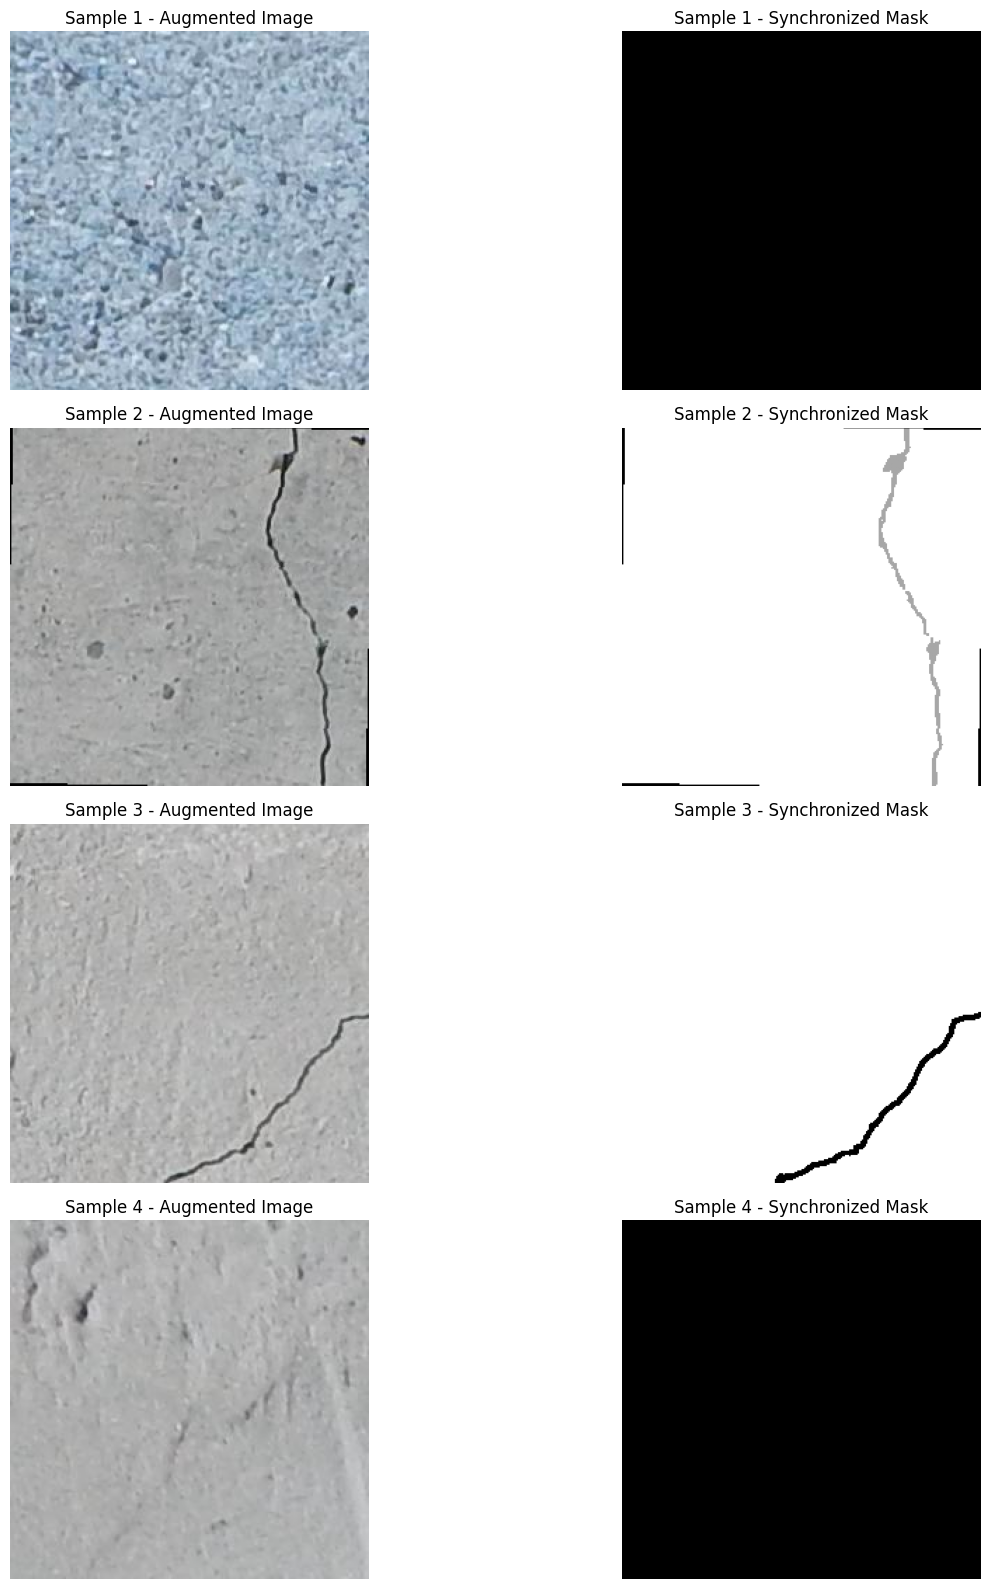


✓ Visualization complete! Please check if the crack positions match exactly.


In [11]:
def denormalize(tensor):
    """Denormalize image tensor back to [0, 1] range"""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1).to(tensor.device)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1).to(tensor.device)
    return torch.clamp(tensor * std + mean, 0, 1)

# Get a fresh batch to check alignment
images, masks = next(iter(train_loader))

print("-" * 80)
print("VERIFYING SYNCHRONIZED ALIGNMENT")
print("-" * 80)

num_samples = min(4, len(images))
plt.figure(figsize=(15, num_samples * 4))

for i in range(num_samples):
    img_display = denormalize(images[i]).permute(1, 2, 0).cpu().numpy()
    mask_display = masks[i].squeeze().cpu().numpy()

    plt.subplot(num_samples, 2, i * 2 + 1)
    plt.imshow(img_display)
    plt.title(f"Sample {i+1} - Augmented Image")
    plt.axis("off")

    plt.subplot(num_samples, 2, i * 2 + 2)
    plt.imshow(mask_display, cmap="gray")
    plt.title(f"Sample {i+1} - Synchronized Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete! Please check if the crack positions match exactly.")

## Define UNet Architecture

In [14]:
class ImprovedUNet(nn.Module):
    """Enhanced UNet with BatchNorm, Dropout, and skip connections"""
    def __init__(self, in_channels=3, out_channels=1, depth=4, start_filters=64):
        super(ImprovedUNet, self).__init__()
        self.depth = depth
        self.start_filters = start_filters

        def conv_block(in_ch, out_ch, dropout=0.2):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Dropout2d(p=dropout),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Dropout2d(p=dropout),
            )

        # Encoder
        self.encoders = nn.ModuleList()
        self.pools = nn.ModuleList()
        in_ch = in_channels
        for i in range(depth):
            out_ch = start_filters * (2 ** i)
            self.encoders.append(conv_block(in_ch, out_ch))
            self.pools.append(nn.MaxPool2d(2))
            in_ch = out_ch

        # Bottleneck
        bottleneck_ch = start_filters * (2 ** depth)
        self.bottleneck = conv_block(in_ch, bottleneck_ch, dropout=0.3)

        # Decoder
        self.decoders = nn.ModuleList()
        self.upconvs = nn.ModuleList()

        for i in range(depth - 1, -1, -1):
            out_ch = start_filters * (2 ** i)
            in_ch_decoder = bottleneck_ch if i == depth - 1 else (start_filters * (2 ** (i + 1)))

            self.upconvs.append(nn.ConvTranspose2d(in_ch_decoder, out_ch, kernel_size=2, stride=2))
            self.decoders.append(conv_block(in_ch_decoder, out_ch))
            bottleneck_ch = out_ch

        # Final output layer
        self.final_conv = nn.Conv2d(start_filters, out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder path
        encoder_outputs = []
        for encoder, pool in zip(self.encoders, self.pools):
            x = encoder(x)
            encoder_outputs.append(x)
            x = pool(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder path
        for i, (upconv, decoder) in enumerate(zip(self.upconvs, self.decoders)):
            x = upconv(x)
            skip = encoder_outputs[-(i + 1)]

            # Handle size mismatches
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)

            x = torch.cat([x, skip], dim=1)
            x = decoder(x)

        # Output
        x = self.final_conv(x)
        x = self.sigmoid(x)
        return x

## Model setup & Training

In [15]:
# Loss Functions for better segmentation

class DiceLoss(nn.Module):
    """Dice Loss for semantic segmentation"""
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = pred.contiguous().view(-1)
        target = target.contiguous().view(-1)

        intersection = (pred * target).sum()
        dice = 1 - (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        return dice

class CombinedLoss(nn.Module):
    """Weighted combination of Dice and BCE Loss"""
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super(CombinedLoss, self).__init__()
        self.bce_loss = nn.BCELoss()
        self.dice_loss = DiceLoss(smooth=1.0)
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, pred, target):
        bce = self.bce_loss(pred, target)
        dice = self.dice_loss(pred, target)
        return self.bce_weight * bce + self.dice_weight * dice

# Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize model with better weights
model = ImprovedUNet(in_channels=3, out_channels=1, depth=4, start_filters=64).to(device)

# Initialize weights properly
for m in model.modules():
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

criterion = CombinedLoss(bce_weight=0.4, dice_weight=0.6)
optimizer = optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-5)  # Higher learning rate
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Using CombinedLoss with BCE weight={0.4}, Dice weight={0.6}")

Using device: cuda
Model parameters: 31,043,521
Using CombinedLoss with BCE weight=0.4, Dice weight=0.6


In [17]:
# Metrics calculation functions

def calculate_metrics(pred, target, threshold=0.5):
    """Calculate Dice, IoU, and F1 scores"""
    # Ensure tensors
    if not isinstance(pred, torch.Tensor):
        pred = torch.from_numpy(pred)
    if not isinstance(target, torch.Tensor):
        target = torch.from_numpy(target)

    pred = pred.float()
    target = target.float()

    pred_binary = (pred > threshold).float()

    # Flatten the tensors
    pred_flat = pred_binary.view(-1)
    target_flat = target.view(-1)

    # True Positive, False Positive, False Negative
    tp = (pred_flat * target_flat).sum().item()
    fp = ((1 - target_flat) * pred_flat).sum().item()
    fn = (target_flat * (1 - pred_flat)).sum().item()

    # Add epsilon for numerical stability
    epsilon = 1e-8

    # Dice score
    dice_den = (2.0 * tp + fp + fn + epsilon)
    dice = (2.0 * tp) / dice_den if dice_den > 0 else 0.0

    # IoU
    iou_den = (tp + fp + fn + epsilon)
    iou = tp / iou_den if iou_den > 0 else 0.0

    # Precision and Recall
    precision_den = (tp + fp + epsilon)
    precision = tp / precision_den if precision_den > 0 else 0.0

    recall_den = (tp + fn + epsilon)
    recall = tp / recall_den if recall_den > 0 else 0.0

    # F1 score
    f1_den = (precision + recall + epsilon)
    f1 = 2 * (precision * recall) / f1_den if f1_den > 0 else 0.0

    # Check for NaN explicitly and replace with 0
    if np.isnan(dice): dice = 0.0
    if np.isnan(iou): iou = 0.0
    if np.isnan(precision): precision = 0.0
    if np.isnan(recall): recall = 0.0
    if np.isnan(f1): f1 = 0.0

    return {
        'dice': float(dice),
        'iou': float(iou),
        'f1': float(f1),
        'precision': float(precision),
        'recall': float(recall)
    }

# Training Loop with Early Stopping and Better Loss

num_epochs = 5
best_val_loss = float('inf')
patience = 15
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': [], 'val_f1': [], 'predictions_sample': []}

print("Starting Training ......\n")
print("-" * 80 , '\n')

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_metrics = {'dice': 0, 'iou': 0, 'f1': 0}

    with tqdm(total=len(train_loader), desc=f"Epoch {epoch+1}/{num_epochs} [Train]", unit='batch') as pbar:
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()

            # Calculate metrics
            with torch.no_grad():
                metrics = calculate_metrics(outputs.detach(), masks.detach())
                train_metrics['dice'] += metrics['dice']
                train_metrics['iou'] += metrics['iou']
                train_metrics['f1'] += metrics['f1']

            pbar.update(1)

    train_loss /= len(train_loader)
    train_metrics = {k: v / len(train_loader) for k, v in train_metrics.items()}

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_metrics = {'dice': 0, 'iou': 0, 'f1': 0, 'precision': 0, 'recall': 0}
    sample_predictions = []

    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(val_loader):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            metrics = calculate_metrics(outputs, masks)
            for key in val_metrics:
                val_metrics[key] += metrics[key]

            # Save sample predictions from first batch
            if batch_idx == 0 and epoch % 5 == 0:
                sample_predictions.append({
                    'epoch': epoch + 1,
                    'pred_min': outputs.min().item(),
                    'pred_max': outputs.max().item(),
                    'pred_mean': outputs.mean().item(),
                    'mask_min': masks.min().item(),
                    'mask_max': masks.max().item(),
                    'mask_mean': masks.mean().item()
                })

    val_loss /= len(val_loader)
    val_metrics = {k: v / len(val_loader) for k, v in val_metrics.items()}

    # Update history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_metrics['dice'])
    history['val_iou'].append(val_metrics['iou'])
    history['val_f1'].append(val_metrics['f1'])

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Print metrics
    print(f"  \nEpoch {epoch+1}/{num_epochs}\n")
    print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}\n")
    print(f"  Val Dice: {val_metrics['dice']:.4f} | Val IoU: {val_metrics['iou']:.4f} | Val F1: {val_metrics['f1']:.4f}\n")
    print(f"  Precision: {val_metrics['precision']:.4f} | Recall: {val_metrics['recall']:.4f}\n")

    # Debug: Show prediction range in early epochs
    if epoch < 5 and len(sample_predictions) > 0:
        sp = sample_predictions[-1]
        print(f"  DEBUG - Pred range: [{sp['pred_min']:.4f}, {sp['pred_max']:.4f}] (mean: {sp['pred_mean']:.4f})\n")
        print(f"  DEBUG - Mask range: [{sp['mask_min']:.4f}, {sp['mask_max']:.4f}] (mean: {sp['mask_mean']:.4f})\n")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_unet_model.pth")
        print("  ✓ Best model saved")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n✓ Early stopping triggered (no improvement for {patience} epochs)")
            break
    print ( '-' * 40 , '\n')

print("\n" + "-" * 80)
print("Training completed!")

# Load best model
model.load_state_dict(torch.load("best_unet_model.pth"))
print("✓ Best model loaded")

# Save training history
with open('training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

Starting Training ......

-------------------------------------------------------------------------------- 



Epoch 1/5 [Train]: 100%|██████████| 40/40 [00:33<00:00,  1.21batch/s]


  
Epoch 1/5

  Train Loss: 0.0175 | Val Loss: 0.0103

  Val Dice: 0.9968 | Val IoU: 0.9936 | Val F1: 0.9968

  Precision: 0.9966 | Recall: 0.9969

  DEBUG - Pred range: [0.0000, 1.0000] (mean: 0.9712)

  DEBUG - Mask range: [0.0000, 1.0000] (mean: 0.9709)

  ✓ Best model saved
---------------------------------------- 



Epoch 2/5 [Train]: 100%|██████████| 40/40 [00:33<00:00,  1.20batch/s]


  
Epoch 2/5

  Train Loss: 0.0135 | Val Loss: 0.0085

  Val Dice: 0.9974 | Val IoU: 0.9948 | Val F1: 0.9974

  Precision: 0.9957 | Recall: 0.9991

  ✓ Best model saved
---------------------------------------- 



...

  
Epoch 3/5

  Train Loss: 0.0145 | Val Loss: 0.1801

  Val Dice: 0.9930 | Val IoU: 0.9861 | Val F1: 0.9930

  Precision: 0.9976 | Recall: 0.9884

---------------------------------------- 



Epoch 4/5 [Train]: 100%|██████████| 40/40 [00:32<00:00,  1.22batch/s]


  
Epoch 4/5

  Train Loss: 0.0217 | Val Loss: 0.0091

  Val Dice: 0.9972 | Val IoU: 0.9944 | Val F1: 0.9972

  Precision: 0.9956 | Recall: 0.9988

---------------------------------------- 



Epoch 5/5 [Train]: 100%|██████████| 40/40 [00:32<00:00,  1.23batch/s]


  
Epoch 5/5

  Train Loss: 0.0141 | Val Loss: 0.0098

  Val Dice: 0.9967 | Val IoU: 0.9934 | Val F1: 0.9967

  Precision: 0.9974 | Recall: 0.9960

---------------------------------------- 


--------------------------------------------------------------------------------
Training completed!
✓ Best model loaded


In [18]:
# Check prediction

if len(history['train_loss']) > 0:
    print("\n" + "-" * 40)
    print("PREDICTION ANALYSIS")
    print("-" * 40)

    model.eval()

    with torch.no_grad():
        # Get a batch to analyze
        test_images, test_masks = next(iter(val_loader))
        test_images, test_masks = test_images.to(device), test_masks.to(device)

        predictions = model(test_images)

        print(f"\nFirst batch predictions analysis:")
        print(f"  Shape: {predictions.shape}")
        print(f"  Min: {predictions.min():.6f}")
        print(f"  Max: {predictions.max():.6f}")
        print(f"  Mean: {predictions.mean():.6f}")
        # Fix: Move the quantile tensor to the same device as predictions
        print(f"  Percentiles [0.1, 0.5, 0.9]: {torch.quantile(predictions.view(-1), torch.tensor([0.1, 0.5, 0.9]).to(device)).tolist()}")

        print(f"\nGround truth masks analysis:")
        print(f"  Min: {test_masks.min():.6f}")
        print(f"  Max: {test_masks.max():.6f}")
        print(f"  Mean: {test_masks.mean():.6f}")
        print(f"  Positive pixels: {(test_masks > 0.5).sum().item()} / {test_masks.numel()}")

        # Try different thresholds
        print(f"\nPredictions at different thresholds:")
        for thresh in [0.1, 0.3, 0.5, 0.7]:
            positive = (predictions > thresh).sum().item()
            pct = (positive / predictions.numel()) * 100
            print(f"  Threshold {thresh}: {positive} pixels ({pct:.2f}%)")

    print("-" * 80)


----------------------------------------
PREDICTION ANALYSIS
----------------------------------------

First batch predictions analysis:
  Shape: torch.Size([16, 1, 256, 256])
  Min: 0.000000
  Max: 1.000000
  Mean: 0.946323
  Percentiles [0.1, 0.5, 0.9]: [0.9976311922073364, 0.9999042749404907, 0.9999567270278931]

Ground truth masks analysis:
  Min: 0.000000
  Max: 1.000000
  Mean: 0.943999
  Positive pixels: 993268 / 1048576

Predictions at different thresholds:
  Threshold 0.1: 999695 pixels (95.34%)
  Threshold 0.3: 995586 pixels (94.95%)
  Threshold 0.5: 993298 pixels (94.73%)
  Threshold 0.7: 990327 pixels (94.44%)
--------------------------------------------------------------------------------


In [21]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create a multi-axis figure
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Training & Validation Loss', 'Validation Dice Score', 'Validation IoU Score', 'Validation F1 Score'),
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

# Helper to add smoothed trace
def add_metric_trace(fig, data, name, row, col, color):
    fig.add_trace(
        go.Scatter(
            y=data,
            mode='lines+markers',
            name=name,
            line=dict(color=color, shape='spline', smoothing=1.3),
            marker=dict(size=4)
        ),
        row=row, col=col
    )

# 1. Loss Plot
fig.add_trace(
    go.Scatter(
        y=history['train_loss'],
        name='Train Loss',
        line=dict(color='blue', width=2, shape='spline', smoothing=1.3)
    ),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(
        y=history['val_loss'],
        name='Val Loss',
        line=dict(color='red', dash='dash', shape='spline', smoothing=1.3)
    ),
    row=1, col=1
)

# 2. Dice Plot
add_metric_trace(fig, history['val_dice'], 'Dice', 1, 2, 'green')

# 3. IoU Plot
add_metric_trace(fig, history['val_iou'], 'IoU', 2, 1, 'orange')

# 4. F1 Plot
add_metric_trace(fig, history['val_f1'], 'F1', 2, 2, 'purple')

# Update layout with custom y-axis ranges for better visibility
fig.update_layout(
    height=800,
    width=1000,
    title_text="Smoothed Training History Analysis (Custom Y-Axis Ranges)",
    showlegend=True,
    template="plotly_white"
)

# Set specific ranges for metrics (assuming they are between 0 and 1)
# We focus on the upper range if the model is performing well
fig.update_yaxes(title_text="Loss", row=1, col=1) # Loss usually auto-scales well
fig.update_yaxes(title_text="Dice Score", range=[0.9, 1.0], row=1, col=2)
fig.update_yaxes(title_text="IoU Score", range=[0.9, 1.0], row=2, col=1)
fig.update_yaxes(title_text="F1 Score", range=[0.9, 1.0], row=2, col=2)

fig.update_xaxes(title_text="Epoch")

fig.show()

## Visualize some Random Predictions

Finding optimal threshold...
  Threshold 0.1: Dice = 0.9961
  Threshold 0.2: Dice = 0.9964
  Threshold 0.3: Dice = 0.9969
  Threshold 0.4: Dice = 0.9972
  Threshold 0.5: Dice = 0.9973
  Threshold 0.6: Dice = 0.9973
  Threshold 0.7: Dice = 0.9969

✓ Best threshold: 0.5 (Dice: 0.9973)

FINAL VALIDATION METRICS
Dice      : 0.9974
Iou       : 0.9947
F1        : 0.9974
Precision : 0.9956
Recall    : 0.9991



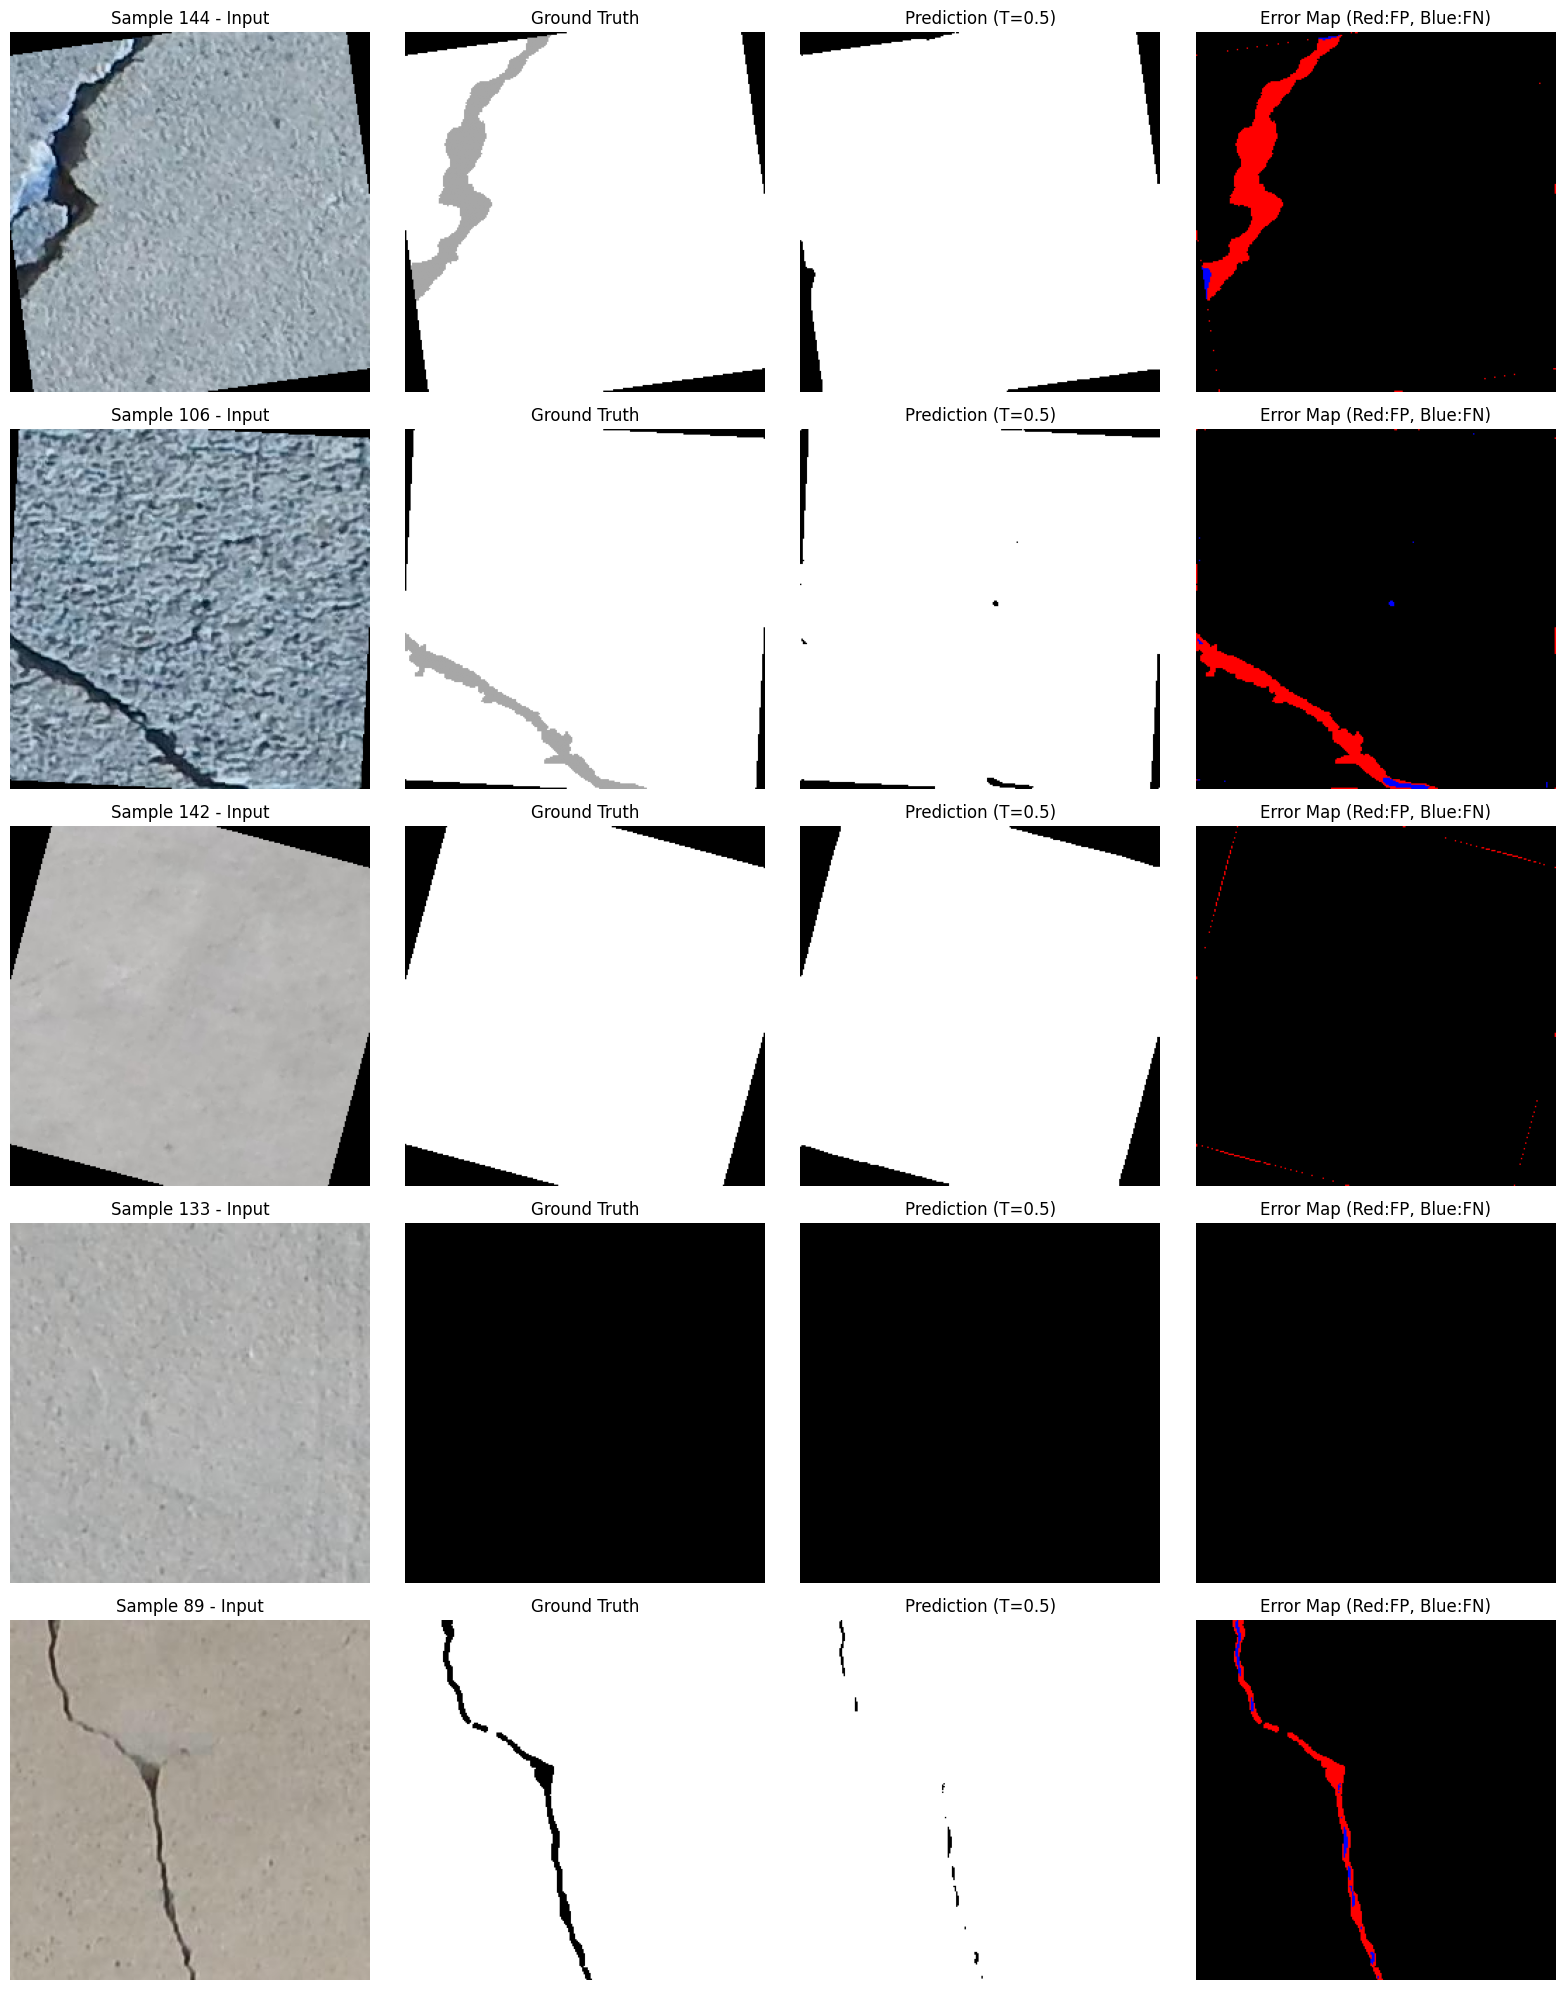

In [23]:
import random

model.eval()

# 1. Determine best threshold dynamically
best_threshold = 0.5
best_dice = 0

print("Finding optimal threshold...")
with torch.no_grad():
    for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
        threshold_dices = []
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            batch_metrics = calculate_metrics(outputs, masks, threshold=threshold)
            threshold_dices.append(batch_metrics['dice'])

        avg_dice = np.mean(threshold_dices)
        print(f"  Threshold {threshold}: Dice = {avg_dice:.4f}")

        if avg_dice > best_dice:
            best_dice = avg_dice
            best_threshold = threshold

print(f"\n✓ Best threshold: {best_threshold} (Dice: {best_dice:.4f})")

# 2. Calculate Final Validation Metrics
final_metrics_list = []
with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        batch_metrics = calculate_metrics(outputs, masks, threshold=best_threshold)
        final_metrics_list.append(batch_metrics)

mean_metrics = {
    k: np.mean([m[k] for m in final_metrics_list]) for k in final_metrics_list[0].keys()
}

print("\n" + "=" * 80)
print("FINAL VALIDATION METRICS")
print("=" * 80)
for k, v in mean_metrics.items():
    print(f"{k.capitalize():<10}: {v:.4f}")
print("=" * 80 + "\n")

# 3. Visualize Random Predictions
num_samples = 5
indices = random.sample(range(len(val_dataset)), num_samples)
fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples * 4))

def denormalize_img(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

for i, idx in enumerate(indices):
    img, mask = val_dataset[idx]
    img_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_tensor)

    img_display = denormalize_img(img).permute(1, 2, 0).cpu().numpy()
    mask_display = mask.squeeze().cpu().numpy()
    pred_display = pred.squeeze().cpu().numpy()
    binary_pred = (pred_display > best_threshold).astype(np.float32)

    # Plot Input
    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title(f"Sample {idx} - Input")
    axes[i, 0].axis('off')

    # Plot GT
    axes[i, 1].imshow(mask_display, cmap='gray')
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis('off')

    # Plot Prediction
    axes[i, 2].imshow(binary_pred, cmap='gray')
    axes[i, 2].set_title(f"Prediction (T={best_threshold})")
    axes[i, 2].axis('off')

    # Plot Error Map (False Positives in Red, False Negatives in Blue)
    error_map = np.zeros((IMG_HEIGHT, IMG_WIDTH, 3))
    error_map[..., 0] = (binary_pred > mask_display).astype(np.float32) # FP
    error_map[..., 2] = (mask_display > binary_pred).astype(np.float32) # FN
    axes[i, 3].imshow(error_map)
    axes[i, 3].set_title("Error Map (Red:FP, Blue:FN)")
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

## Model Export and Summary

In [24]:
# Save model in different formats

# Save PyTorch state dict
torch.save(model.state_dict(), "unet_model_weights.pth")
print("✓ Model weights saved as 'unet_model_weights.pth'")

# Save full model (with architecture)
torch.save(model, "unet_model_full.pth")
print("✓ Full model saved as 'unet_model_full.pth'")

# Save model configuration
model_config = {
    'architecture': 'Improved UNet',
    'in_channels': 3,
    'out_channels': 1,
    'depth': 4,
    'start_filters': 64,
    'image_size': IMG_WIDTH,
    'loss_function': 'Combined Dice + BCE Loss',
    'optimizer': 'AdamW',
    'learning_rate': 1e-3,
    'batch_size': BATCH_SIZE,
    'num_epochs_trained': len(history['train_loss']),
    'final_metrics': mean_metrics,
    'timestamp': datetime.now().isoformat()
}

with open('model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)
print("✓ Model configuration saved as 'model_config.json'")

✓ Model weights saved as 'unet_model_weights.pth'
✓ Full model saved as 'unet_model_full.pth'
✓ Model configuration saved as 'model_config.json'


In [25]:
# Inference function for easy predictions on new images

def predict_crack(image_path, model=None, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """Make prediction on a single image"""
    if model is None:
        model = ImprovedUNet().to(device)
        model.load_state_dict(torch.load("unet_model_weights.pth"))

    model.eval()

    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")
    image = image.resize((IMG_WIDTH, IMG_HEIGHT), Image.Resampling.LANCZOS)
    image_tensor = val_transform(image).unsqueeze(0).to(device)

    # Make prediction
    with torch.no_grad():
        prediction = model(image_tensor)

    return prediction.squeeze().cpu().numpy()

# Test inference function
if len(os.listdir(images_path)) > 0:
    test_image = os.path.join(images_path, os.listdir(images_path)[0])
    pred = predict_crack(test_image, model=model, device=device)
    print(f"✓ Inference function working correctly")
    print(f"  Prediction shape: {pred.shape}")
    print(f"  Prediction range: [{pred.min():.4f}, {pred.max():.4f}]")

✓ Inference function working correctly
  Prediction shape: (256, 256)
  Prediction range: [0.1373, 1.0000]
